In [ ]:
from solar_fork import SeqDataset
from solar_fork import ForecastModel
from solar_fork import evaluate_and_plot


# Initialize dataset
dataset = SeqDataset('./solar_fork/data/data_UT_clean.csv', seq_length=56)
# Initialize forecaster
forecaster = ForecastModel(name="lstm", seq_length=30, input_dim=1)
# Train the model
forecaster.train(dataset.X_train, dataset.y_train, epochs=10, batch_size=32)
forecaster.predict(dataset.X_test, dataset.y_test)

evaluate_and_plot(forecaster, dataset)

ModuleNotFoundError: No module named 'tensorflow'

In [1]:
# --------------------------------------------------------
# 1. Imports
# --------------------------------------------------------
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, GRU, LSTM, Conv1D, Flatten, Dropout, MaxPooling1D, Input, LayerNormalization, MultiHeadAttention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error



2025-08-22 09:38:58.867635: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-22 09:38:58.867665: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-22 09:38:58.867690: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-22 09:38:58.874258: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-22 09:38:59.528415: W tensorflow/compiler/

In [2]:
# --------------------------------------------------------
# 2. Load the Clean Dataset
# --------------------------------------------------------
df = pd.read_csv('data_UT_clean.csv')
df.set_index(df.columns[0], inplace=True)

print(" Loaded dataset:")
print(df.head())

# Features and target
X = df.iloc[:, :-1].values  # All columns except the last one
y = df.iloc[:, -1].values   # Last column

# --------------------------------------------------------
# 3. Normalize Features
# --------------------------------------------------------
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# --------------------------------------------------------
#  4. Create Sequences
# --------------------------------------------------------
def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

# Set how many past steps to use (e.g., 56 steps = 1 day with 15-min intervals (it is not 96 because night times are removed, 06:00 to 19:45h)
seq_length = 56

X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)

print(" Sequence shapes:")
print(f"X_seq: {X_seq.shape}, y_seq: {y_seq.shape}")

# --------------------------------------------------------
#  5. Train-Test Split
# --------------------------------------------------------
split_ratio = 0.8
split_index = int(split_ratio * len(X_seq))

X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

print("Data split:")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

timestamps_test = df.index[seq_length + split_index:]

 Loaded dataset:
               MinuteOfDay  Day  Month  Tair   WS   RH  GHI    P
DateTime                                                        
9/1/2021 6:00          360    1      9   0.0  0.0  0.0  0.0  0.0
9/1/2021 6:15          375    1      9   0.0  0.0  0.0  0.0  0.0
9/1/2021 6:30          390    1      9   0.0  0.0  0.0  0.0  0.0
9/1/2021 6:45          405    1      9   0.0  0.0  0.0  0.0  0.0
9/1/2021 7:00          420    1      9   0.0  0.0  0.0  0.0  0.0
 Sequence shapes:
X_seq: (44240, 56, 7), y_seq: (44240, 1)
Data split:
Train: (35392, 56, 7), Test: (8848, 56, 7)


In [ ]:
# --------------------------------------------------------
# 2. Model Definitions
# --------------------------------------------------------

# RNN model
def build_rnn_model(units=64):
    model = Sequential([
        SimpleRNN(units, input_shape=(seq_length, X_train.shape[2])),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# GRU model
def build_gru_model(units=64):
    model = Sequential([
        GRU(units, input_shape=(seq_length, X_train.shape[2])),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


# LSTM model
def build_lstm_model(units=64, dense_units=64, dropout_rate=0.3, learning_rate=0.001):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(seq_length, X_train.shape[2])),
        LSTM(units),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return model

# CNN model
def build_cnn_model(filters=64, kernel_size=3, dense_units=64, dropout_rate=0.3, learning_rate=0.001):
    model = Sequential([
        Conv1D(filters, kernel_size=kernel_size, activation='relu', input_shape=(seq_length, X_train.shape[2])),
        MaxPooling1D(pool_size=2),
        Conv1D(filters*2, kernel_size=kernel_size, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return model


# TCN model
def build_tcn_model(filters=64, kernel_size=3):
    model = Sequential([
        Conv1D(filters=filters, kernel_size=kernel_size, dilation_rate=1, activation='relu', padding='causal', input_shape=(seq_length, X_train.shape[2])),
        Conv1D(filters=filters, kernel_size=kernel_size, dilation_rate=2, activation='relu', padding='causal'),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Transformer model
def build_transformer_model(embed_dim=56, num_heads=2, ff_dim=64):
    inputs = Input(shape=(seq_length, X_train.shape[2]))
    
    # Positional Encoding can be added, but here we keep simple (check Transformer LSTM.ipynb for positional enconding)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
    x = LayerNormalization()(x)
    
    x = tf.keras.layers.Dense(ff_dim, activation="relu")(x)
    x = tf.keras.layers.Dense(embed_dim)(x)
    x = LayerNormalization()(x)

    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1)(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

# ANN model
def build_ann_model():  
    model = Sequential()
    model.add(Dense(10, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [4]:
# --------------------------------------------------------
# 3. Training Function
# --------------------------------------------------------

def train_model (model, name):
    print(f"\n Training {name} model...")
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)
    return model



In [5]:
# --------------------------------------------------------
# 4. Evaluation and plot
# --------------------------------------------------------

def evaluate_and_plot (model, name):
    print(f" Evaluating {name} model...")
    y_pred = model.predict(X_test)
    y_pred_orig = scaler_y.inverse_transform(y_pred)
    y_test_orig = scaler_y.inverse_transform(y_test)
    
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    mae = mean_absolute_error(y_test_orig, y_pred_orig)

    nRMSE = np.sqrt(mse)/(y_test_orig.max()-y_test_orig.min())
    nMAE = (mae)/(y_test_orig.max()-y_test_orig.min())
    
    print(f"{name} Test MSE: {mse:.4f}")
    print(f"{name} Test MAE: {mae:.4f}")
    print(f"{name} Test nRMSE: {nRMSE:.4f}")
    print(f"{name} Test nMAE: {nMAE:.4f}")
    

    df_result = pd.DataFrame(
        np.hstack((y_test_orig, y_pred_orig)),
        columns=['Measurement', 'Prediction'])
    
    df_result_error = pd.DataFrame({
        'MSE': mse,
        'MAE': mae,
        'nRMSE':nRMSE,
        'nMAE':nMAE}, index=['error'])
    
    df_result_error.to_csv(f'{name} Forecast Result-Erros.csv')
    df_result.to_csv(f'{name} Forecast Result.csv')
    


    #prepare for plotting
    timestamps_test = df.index[seq_length + split_index:]
    ts=timestamps_test.to_numpy()
    y_test_orig=y_test_orig.reshape(-1)
    a=30*56 #start_index
    b=a+7*56 # end_index, every day consists of 56 instances
    tick_show= 8 # every 15 minutes * ticks_show for lables on Xtick, e.g. 4 means 4*15 min =60 mins 1 hour
    ts_trunc=ts[a:b]
    #y_pred_best_orig_trunc=y_pred_best_orig[a:b] #best
    y_pred_orig_trunc=y_pred_orig[a:b]
    y_test_orig_trunc=y_test_orig[a:b]
    
    #plot
    plt.figure(figsize=(18, 6))
    plt.plot(ts_trunc, y_test_orig_trunc, label='Measurement')
    plt.plot(ts_trunc, y_pred_orig_trunc, label=f'Prediction by {name}')
    plt.legend()
    plt.title(f'Forecast by {name}')
    plt.xlabel('Time')
    plt.ylabel('PV Power [W]')
    plt.xticks(ticks=range(0, len(ts_trunc), tick_show), labels=[ts_trunc[i] for i in range(0, len(ts_trunc), tick_show)],rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{name} Forecast.png')
    plt.show()
    return nRMSE, nMAE 


📚 Training RNN model...
Epoch 1/20
885/885 [==============================] - 10s 11ms/step - loss: 0.1343 - val_loss: 0.1946
Epoch 2/20
885/885 [==============================] - 9s 11ms/step - loss: 0.1129 - val_loss: 0.1717
Epoch 3/20
885/885 [==============================] - 9s 11ms/step - loss: 0.1087 - val_loss: 0.1749
Epoch 4/20
885/885 [==============================] - 10s 11ms/step - loss: 0.1077 - val_loss: 0.1687
Epoch 5/20
885/885 [==============================] - 9s 11ms/step - loss: 0.1056 - val_loss: 0.1702
Epoch 6/20
885/885 [==============================] - 9s 11ms/step - loss: 0.1034 - val_loss: 0.1741
Epoch 7/20
885/885 [==============================] - 9s 11ms/step - loss: 0.1018 - val_loss: 0.1808
Epoch 8/20
885/885 [==============================] - 9s 11ms/step - loss: 0.1006 - val_loss: 0.1832
Epoch 9/20
885/885 [==============================] - 9s 11ms/step - loss: 0.0990 - val_loss: 0.1908
Epoch 10/20
885/885 [==============================] - 10s 11ms/

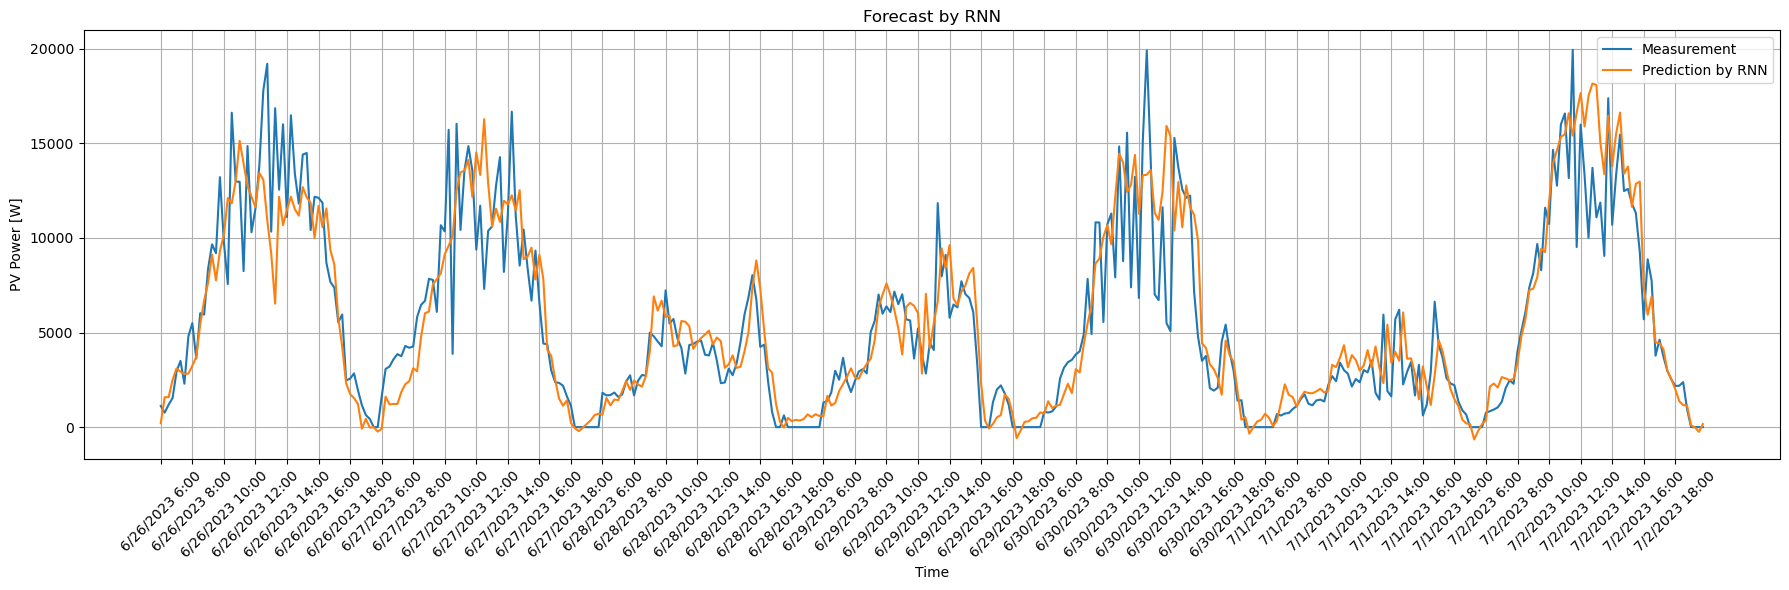

(0.10053532241455372, 0.06327351581735682)

In [6]:
# --------------------------------------------------------
# 5. Build, 5rain and plot models
# --------------------------------------------------------

# RNN
rnn_model = build_rnn_model(units=64)
train_model(rnn_model, "RNN")
evaluate_and_plot(rnn_model, "RNN")


📚 Training GRU model...
Epoch 1/20
885/885 [==============================] - 24s 25ms/step - loss: 0.1255 - val_loss: 0.1665
Epoch 2/20
885/885 [==============================] - 22s 25ms/step - loss: 0.1073 - val_loss: 0.1604
Epoch 3/20
885/885 [==============================] - 22s 25ms/step - loss: 0.1043 - val_loss: 0.1686
Epoch 4/20
885/885 [==============================] - 22s 25ms/step - loss: 0.1028 - val_loss: 0.1637
Epoch 5/20
885/885 [==============================] - 22s 25ms/step - loss: 0.1008 - val_loss: 0.1701
Epoch 6/20
885/885 [==============================] - 22s 25ms/step - loss: 0.0996 - val_loss: 0.1676
Epoch 7/20
885/885 [==============================] - 22s 25ms/step - loss: 0.0980 - val_loss: 0.1634
Epoch 8/20
885/885 [==============================] - 22s 25ms/step - loss: 0.0963 - val_loss: 0.1703
Epoch 9/20
885/885 [==============================] - 22s 25ms/step - loss: 0.0949 - val_loss: 0.1653
Epoch 10/20
885/885 [==============================] - 22

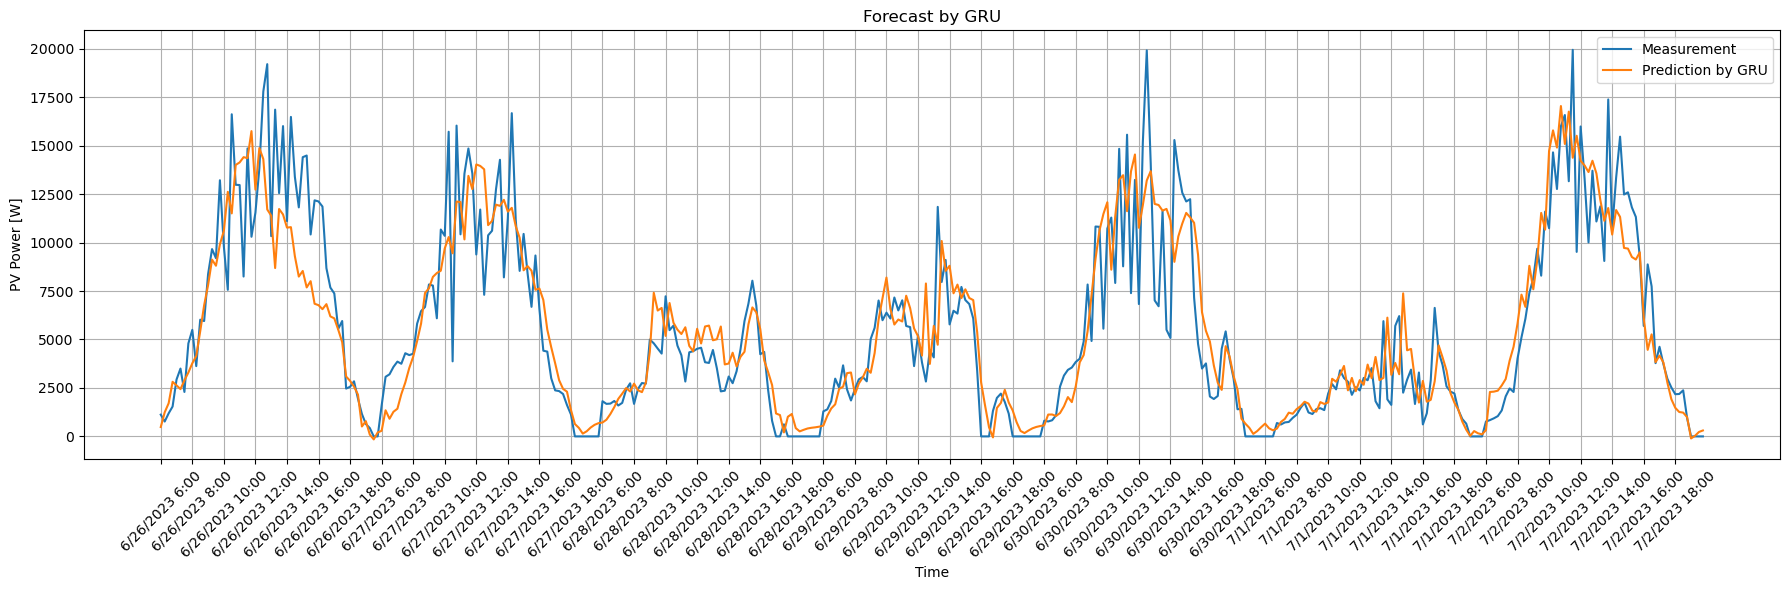

(0.10350535105756317, 0.0646997844219144)

In [7]:
# GRU
gru_model = build_gru_model(units=64)
train_model(gru_model,"GRU")
evaluate_and_plot(gru_model, "GRU")



📚 Training LSTM model...
Epoch 1/20
885/885 [==============================] - 48s 52ms/step - loss: 0.1543 - val_loss: 0.1725
Epoch 2/20
885/885 [==============================] - 46s 52ms/step - loss: 0.1245 - val_loss: 0.1722
Epoch 3/20
885/885 [==============================] - 45s 51ms/step - loss: 0.1167 - val_loss: 0.1707
Epoch 4/20
885/885 [==============================] - 46s 52ms/step - loss: 0.1153 - val_loss: 0.1729
Epoch 5/20
885/885 [==============================] - 45s 51ms/step - loss: 0.1124 - val_loss: 0.1657
Epoch 6/20
885/885 [==============================] - 46s 52ms/step - loss: 0.1108 - val_loss: 0.1647
Epoch 7/20
586/885 [==================>...........] - ETA: 14s - loss: 0.1066

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



885/885 [==============================] - 46s 52ms/step - loss: 0.0993 - val_loss: 0.1696
Epoch 14/20
885/885 [==============================] - 46s 52ms/step - loss: 0.0981 - val_loss: 0.1698
Epoch 15/20
885/885 [==============================] - 46s 52ms/step - loss: 0.0972 - val_loss: 0.1713
Epoch 16/20
885/885 [==============================] - 45s 51ms/step - loss: 0.0953 - val_loss: 0.1744
Epoch 17/20
885/885 [==============================] - 45s 51ms/step - loss: 0.0938 - val_loss: 0.1744
Epoch 18/20
885/885 [==============================] - 45s 51ms/step - loss: 0.0931 - val_loss: 0.1822
Epoch 19/20
885/885 [==============================] - 46s 52ms/step - loss: 0.0905 - val_loss: 0.1753
Epoch 20/20
885/885 [==============================] - 46s 52ms/step - loss: 0.0896 - val_loss: 0.1779
 Evaluating LSTM model...
277/277 [==============================] - 5s 17ms/step
LSTM Test MSE: 4765455.3607
LSTM Test MAE: 1373.7079
LSTM Test nRMSE: 0.1043
LSTM Test nMAE: 0.0656


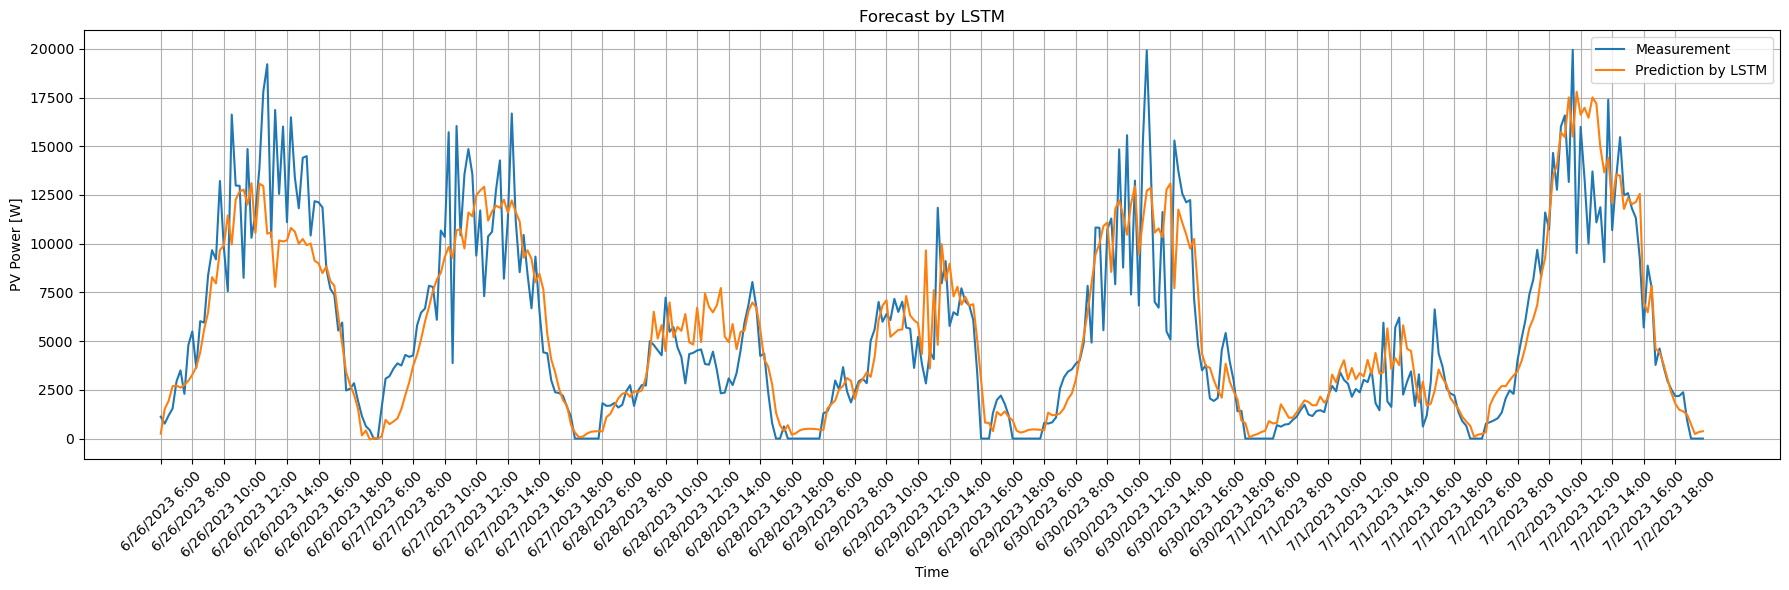

(0.10425982878722209, 0.06560836169954162)

In [8]:
# LSTM
lstm_model=build_lstm_model()
train_model(lstm_model, "LSTM")
evaluate_and_plot(lstm_model, "LSTM")

In [ ]:
# CNN
cnn_model=build_cnn_model()
#cnn_model=build_cnn_model(filters=32, kernel_size=5, dense_units=32, dropout_rate=0.3, learning_rate=0.0005) #with hp tuning

train_model(cnn_model, "CNN")
evaluate_and_plot(cnn_model, "CNN")


📚 Training CNN model...
Epoch 1/20
885/885 [==============================] - 6s 6ms/step - loss: 0.2005 - val_loss: 0.2601
Epoch 2/20
144/885 [===>..........................] - ETA: 3s - loss: 0.1751

885/885 [==============================] - 4s 4ms/step - loss: 0.1020 - val_loss: 0.1882
Epoch 4/20
885/885 [==============================] - 4s 5ms/step - loss: 0.0967 - val_loss: 0.1801
Epoch 5/20
885/885 [==============================] - 4s 5ms/step - loss: 0.0911 - val_loss: 0.1880
Epoch 6/20
885/885 [==============================] - 4s 5ms/step - loss: 0.0844 - val_loss: 0.1824
Epoch 7/20
885/885 [==============================] - 4s 5ms/step - loss: 0.0790 - val_loss: 0.1906
Epoch 8/20
885/885 [==============================] - 4s 5ms/step - loss: 0.0736 - val_loss: 0.1887
Epoch 9/20
885/885 [==============================] - 4s 5ms/step - loss: 0.0655 - val_loss: 0.1979
Epoch 10/20
885/885 [==============================] - 4s 5ms/step - loss: 0.0597 - val_loss: 0.1968
Epoch 11/20
885/885 [==============================] - 4s 4ms/step - loss: 0.0529 - val_loss: 0.2059
Epoch 12/20
885/885 [==============================] - 4s 5ms/step - loss: 0.0471 - val_loss: 0.2048
Epoch 13

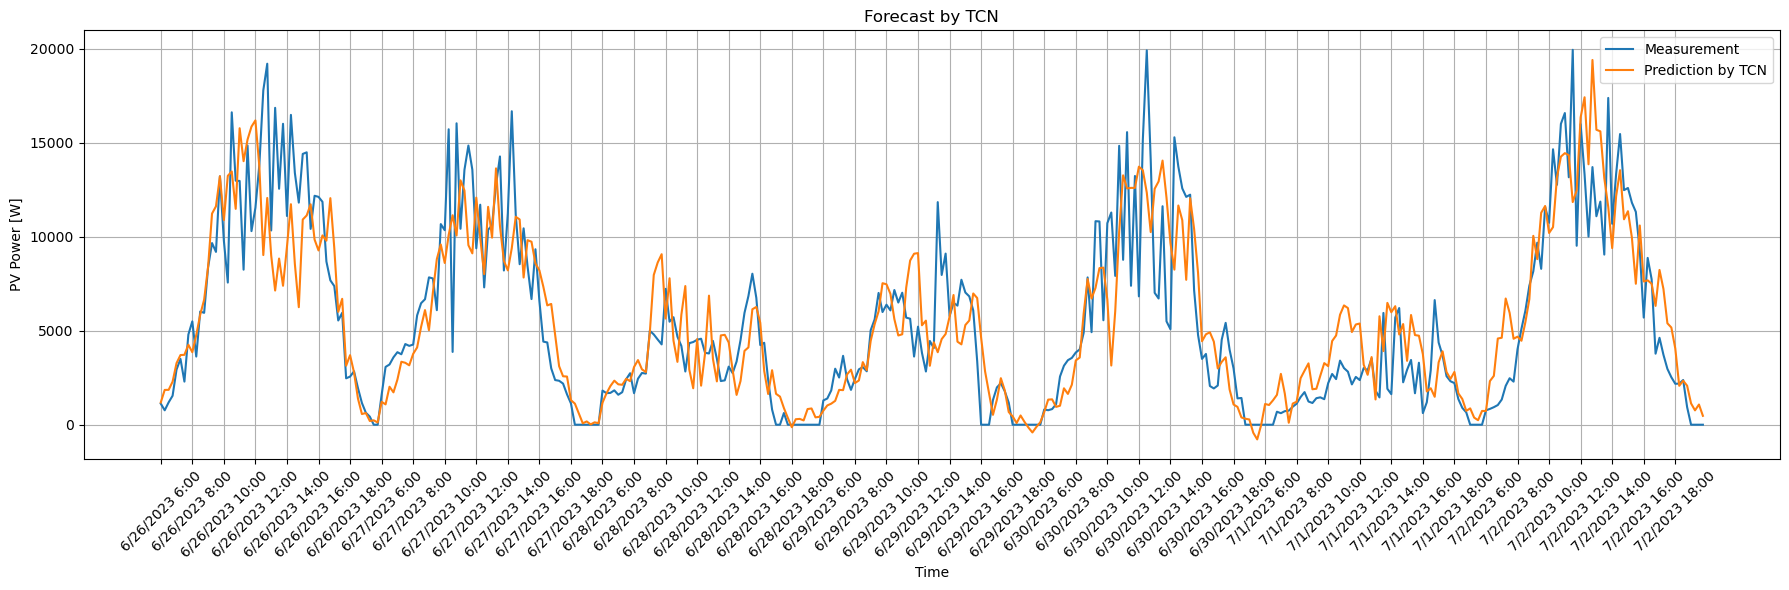

(0.11510586529333082, 0.07453056223416778)

In [10]:
# TCN
tcn_model = build_tcn_model(filters=64, kernel_size=3)
train_model(tcn_model, "TCN")
evaluate_and_plot(tcn_model,"TCN")

In [11]:
# Transformer
transformer_model = build_transformer_model(embed_dim=32, num_heads=2, ff_dim=64)
train_model(transformer_model, "Transformer")
evaluate_and_plot(transformer_model, "Transformer")



📚 Training Transformer model...
Epoch 1/20
885/885 [==============================] - 15s 16ms/step - loss: 0.2256 - val_loss: 0.2124
Epoch 2/20
885/885 [==============================] - 14s 15ms/step - loss: 0.1255 - val_loss: 0.1794
Epoch 3/20
885/885 [==============================] - 14s 15ms/step - loss: 0.1165 - val_loss: 0.1839
Epoch 4/20
885/885 [==============================] - 14s 15ms/step - loss: 0.1114 - val_loss: 0.1972
Epoch 5/20
885/885 [==============================] - 13s 15ms/step - loss: 0.1096 - val_loss: 0.2148
Epoch 6/20
885/885 [==============================] - 14s 15ms/step - loss: 0.1074 - val_loss: 0.1787
Epoch 7/20
885/885 [==============================] - 13s 15ms/step - loss: 0.1035 - val_loss: 0.1806
Epoch 8/20
885/885 [==============================] - 13s 15ms/step - loss: 0.1010 - val_loss: 0.1733
Epoch 9/20
885/885 [==============================] - 13s 15ms/step - loss: 0.0992 - val_loss: 0.1872
Epoch 10/20
885/885 [============================

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [12]:
# MLP
mlp_model = build_ann_model()
train_model(mlp_model, "MLP")
evaluate_and_plot(mlp_model, "MLP")


📚 Training MLP model...
Epoch 1/20
885/885 [==============================] - 2s 2ms/step - loss: 0.7892 - val_loss: 0.8389
Epoch 2/20
885/885 [==============================] - 1s 1ms/step - loss: 0.6754 - val_loss: 0.8243
Epoch 3/20
885/885 [==============================] - 1s 1ms/step - loss: 0.6677 - val_loss: 0.8052
Epoch 4/20
885/885 [==============================] - 1s 1ms/step - loss: 0.6636 - val_loss: 0.7997
Epoch 5/20
885/885 [==============================] - 1s 1ms/step - loss: 0.6608 - val_loss: 0.7976
Epoch 6/20
885/885 [==============================] - 1s 1ms/step - loss: 0.6588 - val_loss: 0.7991
Epoch 7/20
885/885 [==============================] - 1s 1ms/step - loss: 0.6575 - val_loss: 0.7929
Epoch 8/20
885/885 [==============================] - 1s 1ms/step - loss: 0.6562 - val_loss: 0.7899
Epoch 9/20
885/885 [==============================] - 1s 1ms/step - loss: 0.6556 - val_loss: 0.7943
Epoch 10/20
885/885 [==============================] - 1s 1ms/step - loss: 

In [ ]:
56, 7
# MLP
mlp_model = build_ann_model()
train_model(mlp_model, "MLP")
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)


In [13]:
56, 7

 Evaluating MLP model...
277/277 [==============================] - 0s 641us/step


ValueError: Found array with dim 3, while dim <= 2 is required.

In [ ]:
# --------------------------------------------------------
# 6. Benchmark - Persistent
# --------------------------------------------------------

def evaluate_and_plot_persistent (name):
    print(f" Evaluating {name} model...")
    
   

    y_pred_x = y_test[:-56]
    y_pred=np.insert(y_pred_x, 0, y_train[-56:].flatten()).reshape(-1, 1) #add the first day from the training
    #print(f"{name} test shape: {np.shape(y_test)}")
    #print(f"{name} pred shape: {np.shape(y_pred)}")
    y_pred_orig = scaler_y.inverse_transform(y_pred)
    y_test_orig = scaler_y.inverse_transform(y_test)
    
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    mae = mean_absolute_error(y_test_orig, y_pred_orig)

    nRMSE = np.sqrt(mse)/(y_test_orig.max()-y_test_orig.min())
    nMAE = (mae)/(y_test_orig.max()-y_test_orig.min())
    
    print(f"{name} Test MSE: {mse:.4f}")
    print(f"{name} Test MAE: {mae:.4f}")
    print(f"{name} Test nRMSE: {nRMSE:.4f}")
    print(f"{name} Test nMAE: {nMAE:.4f}")
    
    df_result = pd.DataFrame(
        np.hstack((y_test_orig, y_pred_orig)),
        columns=['Measurement', 'Prediction'])
    
    df_result_error = pd.DataFrame({
        'MSE': mse,
        'MAE': mae,
        'nRMSE':nRMSE,
        'nMAE':nMAE}, index=['error'])
    
    df_result_error.to_csv(f'{name} Forecast Result-Erros.csv')
    df_result.to_csv(f'{name} Forecast Result.csv')
    
    #prepare for plotting
    timestamps_test = df.index[seq_length + split_index:]
    ts=timestamps_test.to_numpy()
    y_test_orig=y_test_orig.reshape(-1)
    a=30*56 #start_index
    b=a+7*56 # end_index, every day consists of 56 instances
    tick_show= 8 # every 15 minutes * ticks_show for lables on Xtick, e.g. 4 means 4*15 min =60 mins 1 hour
    ts_trunc=ts[a:b]
    #y_pred_best_orig_trunc=y_pred_best_orig[a:b] #best
    y_pred_orig_trunc=y_pred_orig[a:b]
    y_test_orig_trunc=y_test_orig[a:b]
    
    #plot
    plt.figure(figsize=(18, 6))
    plt.plot(ts_trunc, y_test_orig_trunc, label='Measurement')
    plt.plot(ts_trunc, y_pred_orig_trunc, label=f'Prediction by {name}')
    plt.legend()
    plt.title(f'Forecast by {name}')
    plt.xlabel('Time')
    plt.ylabel('PV Power [W]')
    plt.xticks(ticks=range(0, len(ts_trunc), tick_show), labels=[ts_trunc[i] for i in range(0, len(ts_trunc), tick_show)],rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{name} Forecast.png')
    plt.show()
    return nRMSE, nMAE, 

evaluate_and_plot_persistent('Persistence')

In [ ]:
# --------------------------------------------------------
# 7. Compare models
# --------------------------------------------------------

names = ['Persistence','RNN', 'GRU', 'LSTM','CNN','TCN','Transformer']

# Read each DataFrame and extract column 'Prediction', renaming it to 'Pred_<name>'
dfs = []
for name in names:
    df = pd.read_csv(f"Results/{name} Forecast Result.csv")  
    col = df[['Prediction']].rename(columns={'Prediction': f'Pred_{name}'})
    if name == 'Persistence':
        col_measurement = df[['Measurement']]
        dfs.append(col_measurement)
    dfs.append(col)


# Concatenate all the renamed columns into a single DataFrame
combined_df = pd.concat(dfs, axis=1)
combined_df.set_index(timestamps_test, inplace=True)
combined_df.to_csv(f'All Forecasts Result.csv')

print(combined_df.head())

In [ ]:
# --------------------------------------------------------
# 8. Plot Results (part of dataset)
# --------------------------------------------------------

a=30*56 #start_index, e.g. here is 30, means that we start drawing plot from 30th day in the test dataset
d=1  #number of days you would like to plot
b=a+d*56  # end_index, every day consists of 56 instances
tick_show= 2 # every 15 minutes * ticks_show for lables on Xtick, e.g. 4 means 4*15 min =60 mins 1 hour

#combined_df = pd.read_csv(f'All Forecasts Result.csv')
df_selected = combined_df.iloc[a:b]
ts_trunc=df_selected.index.to_numpy()

# Plot each column as a separate profile
plt.figure(figsize=(18, 9))
plt.plot(ts_trunc, df_selected['Measurement'].to_numpy(), label='Measurement',linestyle='--')
plt.plot(ts_trunc, df_selected['Pred_Persistence'].to_numpy(), label='Persistence',linestyle=':')
plt.plot(ts_trunc, df_selected['Pred_RNN'].to_numpy(), label='RNN',marker='o',linewidth=2,linestyle='-.')
plt.plot(ts_trunc, df_selected['Pred_GRU'].to_numpy(),label='GRU', marker='x',linewidth=2,linestyle='-')
plt.plot(ts_trunc, df_selected['Pred_LSTM'].to_numpy(), label='LSTM', marker='s',linewidth=2)
plt.plot(ts_trunc, df_selected['Pred_CNN'].to_numpy(), label='CNN', marker='^',linewidth=2)
plt.plot(ts_trunc, df_selected['Pred_TCN'].to_numpy(), label='TCN', marker='*',linewidth=2)
plt.plot(ts_trunc, df_selected['Pred_Transformer'].to_numpy(), label='Transformer', marker='p',linewidth=2)

plt.title('Forecast comparison')
plt.xlabel('Time')
plt.ylabel('PV Power [W]')
plt.xticks(ticks=range(0, len(ts_trunc), tick_show), labels=[ts_trunc[i] for i in range(0, len(ts_trunc), tick_show)],rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.grid(True)
plt.savefig(f'All forecasts for {d} days.png')
plt.show()